In [47]:
# Importação de bibliotecas
import matplotlib.pyplot as plt
from matplotlib.widgets import Slider
import numpy as np

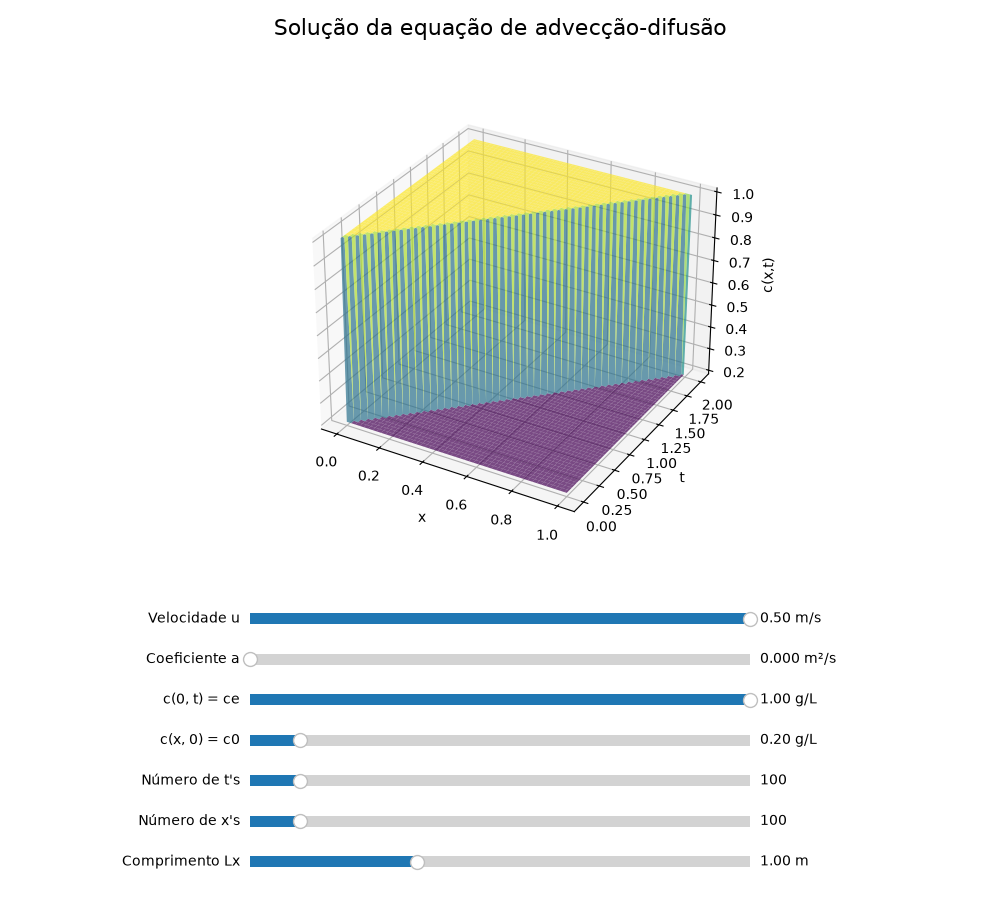

In [ ]:
%matplotlib widget

def FTCS(Qnj, Qnjforward, Qnjbackward, dt, dx, u, a):
    Qnforwardj = Qnj - (dt / dx) * u * (Qnj - Qnjbackward) + (dt / dx**2) * a * (Qnjforward - 2 * Qnj + Qnjbackward)
    return Qnforwardj

def apply_method(function, T, numTs, Lx, numXs, u, a, ce, c0):
    Q = np.zeros((numTs, numXs))

    # if (u == 0 and a == 0):
    #     print("\n!!! Velocidade de advecção (u) e o coeficiente de difusão (a) não podem ser nulos simultaneamente. !!!\n")
    #     return Q
    # elif (u == 0):
    #     print("u = 0. Regime puramente difusivo.")
    # elif (a == 0):
    #     print("a = 0. Regime puramente advectivo.")
    # elif (u < 0):
    #     print("\n!!! Velocidade de advecção (u) deve ser maior ou igual a zero. !!!\n")
    #     return Q

    # if (ce <= c0):
    #     print("\n!!! ce deve ser maior que c0. !!!")
    #     return Q

    dt = T/numTs
    dx = Lx/numXs

    # dtmax = dx**2 / (u * dx + 2 * a)
    # if (dt > dtmax):
    #     print(f"\n! Δt = {dt} > Δtmax = {dtmax}. A solução pode não ser estável. !\n")

    # Condições iniciais
    Q[:, 0] = ce # c(x=0, t)
    Q[0, :] = c0 # c(x, t=0)

    for n in range(0, numTs-1):
        for j in range(1, numXs-1):
            Q[n+1, j] = function(Q[n, j], Q[n, j+1], Q[n, j-1], dt, dx, u, a)

        # Condição de contorno de saída com aproximação recuada de 1ª ordem
        Q[n+1, -1] = Q[n+1, -2]

    return Q


def interactive_plot(method, T, numTs, Lx, numXs, u, a, ce, c0):
    plt.close('all')
    fig = plt.figure(figsize=(10, 9))
    fig.subplots_adjust(bottom=0.4, top=0.9)
    fig.suptitle('Solução da equação de advecção-difusão', fontsize=16)
    fig.canvas.manager.set_window_title('')
    ax = fig.add_subplot(1, 1, 1, projection='3d')

    # Criação dos sliders (posicionados abaixo do gráfico)
    slider_h = 0.025 # altura de cada slider
    spacing = 0.045 # espaçamento vertical entre sliders
    left = 0.25
    width = 0.5
    base = 0.03 # posição y do slider mais baixo

    ax_Lx = fig.add_axes([left, base + 0 * spacing, width, slider_h])
    ax_nx = fig.add_axes([left, base + 1 * spacing, width, slider_h])
    ax_nt = fig.add_axes([left, base + 2 * spacing, width, slider_h])
    ax_c0 = fig.add_axes([left, base + 3 * spacing, width, slider_h])
    ax_ce = fig.add_axes([left, base + 4 * spacing, width, slider_h])
    ax_a  = fig.add_axes([left, base + 5 * spacing, width, slider_h])
    ax_u  = fig.add_axes([left, base + 6 * spacing, width, slider_h])

    slider_u  = Slider(ax=ax_u,  label='Velocidade u',   valmin=0.0,   valmax=0.5,    valinit=u,     valfmt='%1.2f m/s')
    slider_a  = Slider(ax=ax_a,  label='Coeficiente a',  valmin=0.0,   valmax=0.01,   valinit=a,     valfmt='%1.3f m²/s')
    slider_ce = Slider(ax=ax_ce, label='c(0, t) = ce',   valmin=0.7,   valmax=1.0,    valinit=ce,    valfmt='%1.2f g/L')
    slider_c0 = Slider(ax=ax_c0, label='c(x, 0) = c0',   valmin=0.0,   valmax=2.0,    valinit=c0,    valfmt='%1.2f g/L')
    slider_nt = Slider(ax=ax_nt, label="Número de t's",  valmin=1.0,   valmax=1000.0, valinit=numTs, valfmt='%1.0f')
    slider_nx = Slider(ax=ax_nx, label="Número de x's",  valmin=1.0,   valmax=1000.0, valinit=numXs, valfmt='%1.0f')
    slider_Lx = Slider(ax=ax_Lx, label="Comprimento Lx", valmin=0.5,   valmax=2.0,    valinit=Lx,    valfmt='%1.2f m')

    Q = apply_method(method, T, numTs, Lx, numXs, u, a, ce, c0)
    x = np.linspace(0, Lx, numXs)
    t = np.linspace(0, T, numTs)
    X, T_grid = np.meshgrid(x, t)
    f_d = ax.plot_surface(X, T_grid, Q, cmap='viridis', alpha=0.7)

    def update(val):
        nonlocal f_d
        u = slider_u.val
        a = slider_a.val
        ce = slider_ce.val
        c0 = slider_c0.val
        numTs = int(slider_nt.val)
        numXs = int(slider_nx.val)
        Lx = slider_Lx.val

        Q = apply_method(method, T, numTs, Lx, numXs, u, a, ce, c0)
        x = np.linspace(0, Lx, numXs)
        t = np.linspace(0, T, numTs)
        X, T_grid = np.meshgrid(x, t)

        f_d.remove()
        f_d = ax.plot_surface(X, T_grid, Q, cmap='viridis', alpha=0.7)
        fig.canvas.draw_idle()

    slider_u.on_changed(update)
    slider_a.on_changed(update)
    slider_ce.on_changed(update)
    slider_c0.on_changed(update)
    slider_nt.on_changed(update)
    slider_nx.on_changed(update)
    slider_Lx.on_changed(update)

    ax.set_xlabel('x [m]')
    ax.set_ylabel('t [s]')
    ax.set_zlabel('c(x,t) [g/L]')

    plt.show()

def main_interactive():
    # Malha
    Lx = 1.0
    nx = 100
    T = 2.0
    nt = 100

    # Constantes
    u = 0.5
    a = 0

    # Condição inicial
    c0 = 0.2

    # Condição de contorno de entrada
    ce = 1

    interactive_plot(FTCS, T, nt, Lx, nx, u, a, ce, c0)

main_interactive()
